In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# About Data

We want to predict the **price** of a car given its characteristics (features).
This is called a supervised regression problem because:

**Input** = features (like year , engine size, Model…)

**Output** = continuous value (price, e.g., 25760.290347 ).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load the dataset from a CSV file
df = pd.read_csv("/content/drive/MyDrive/AI MASTER CLASS BRAINER X AUG 2025/AI MASTER CLASS BRAINERX CONTENT/notebooks/datasets/Car_Price_Prediction.csv")
# Print the shape (rows, columns)
print(f"Dataset shape: {df.shape}")

# Display the first 5 rows to get a feel for the data
print("\nFirst 5 rows of the dataset:")
display(df.head())

Dataset shape: (1000, 8)

First 5 rows of the dataset:


,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1000.0,2010.68800,6.288577,2000.000000,2005.00000,2011.000000,2016.000000,2021.000000
Engine Size,1000.0,2.79830,1.024137,1.000000,1.90000,2.800000,3.700000,4.500000
Mileage,1000.0,97192.48700,59447.315760,56.000000,44768.75000,94411.500000,148977.750000,199867.000000
Price,1000.0,25136.61553,5181.401368,6704.953524,21587.87837,25189.325247,28806.368974,41780.504635


# Data preprocessing

## Report

What you’re describing is a data exploration and reporting function — something that:

*   Detects problems ("bugs") like missing values, wrong data types, duplicates
*   Gives suggestions on how to handle them (e.g., impute missing values, encode categorical features, scale numeric ones).



In [ ]:
import pandas as pd
import numpy as np

def report_dataframe(df: pd.DataFrame,
                     high_card_limit: int = 100,
                     verbose: bool = True) -> dict:
    report = {}

    def log(msg):
        if verbose:
            print(f"[INFO] {msg}")

    # 1. Missing values
    null_report = df.isnull().sum()
    null_report = null_report[null_report > 0]
    if not null_report.empty:
        log(f"Missing values found:\n{null_report}")
        report['missing_values'] = null_report.to_dict()

    # 2. Duplicate rows
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        log(f"Duplicate rows found: {dup_count}")
        report['duplicates'] = dup_count

    # 3. Constant columns
    constant_cols = [col for col in df.columns if df[col].nunique() == 1]
    if constant_cols:
        log(f"Constant columns (consider removing): {constant_cols}")
        report['constant_cols'] = constant_cols

    # 4. High-cardinality categoricals
    high_card_cols = [col for col in df.select_dtypes(include='object')
                      if df[col].nunique() > high_card_limit]
    if high_card_cols:
        log(f"High-cardinality columns: {high_card_cols}")
        report['high_cardinality'] = high_card_cols


    # 5. Numeric outliers (IQR method)
    num_cols = df.select_dtypes(include=np.number).columns
    outlier_report = {}
    for col in num_cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
        if outliers > 0:
            outlier_report[col] = int(outliers)
    if outlier_report:
        log(f"Outliers detected:\n{outlier_report}")
        report['outliers'] = outlier_report

    log("Report generation complete.")
    return report

report = report_dataframe(df, high_card_limit=50)

[INFO] Outliers detected:
{'Price': 3}
[INFO] Report generation complete.


## Some Feature engineering

In [ ]:
CURRENT_YEAR = 2025
df['vehicle_age'] = CURRENT_YEAR - df['Year']

In [ ]:
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price,vehicle_age
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931,10
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684,11
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347,19
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491,10
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657,21


## Data Enconding

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col} → {df[col].unique()}")

Make → ['Honda' 'Ford' 'BMW' 'Audi' 'Toyota']
Model → ['Model B' 'Model C' 'Model A' 'Model D' 'Model E']
Fuel Type → ['Petrol' 'Electric' 'Diesel']
Transmission → ['Manual' 'Automatic']


In [ ]:
df_encoded = pd.get_dummies(df, columns=["Make", "Model", "Fuel Type"], drop_first=True)
df_encoded.head()

,Year,Engine Size,Mileage,Transmission,Price,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
0,2015,3.9,74176,Manual,30246.207931,10,False,False,True,False,True,False,False,False,False,True
1,2014,1.7,94799,Automatic,22785.747684,11,False,True,False,False,False,True,False,False,True,False
2,2006,4.1,98385,Manual,25760.290347,19,True,False,False,False,True,False,False,False,True,False
3,2015,2.6,88919,Automatic,25638.003491,10,False,False,True,False,True,False,False,False,True,False
4,2004,3.4,138482,Automatic,21021.386657,21,False,False,True,False,False,True,False,False,False,True


In [ ]:
le = LabelEncoder()
df_encoded["Transmission"] = le.fit_transform(df_encoded[["Transmission"]])
df_encoded.head()

,Year,Engine Size,Mileage,Transmission,Price,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
0,2015,3.9,74176,1,30246.207931,10,False,False,True,False,True,False,False,False,False,True
1,2014,1.7,94799,0,22785.747684,11,False,True,False,False,False,True,False,False,True,False
2,2006,4.1,98385,1,25760.290347,19,True,False,False,False,True,False,False,False,True,False
3,2015,2.6,88919,0,25638.003491,10,False,False,True,False,True,False,False,False,True,False
4,2004,3.4,138482,0,21021.386657,21,False,False,True,False,False,True,False,False,False,True


## Data Splitting

In [ ]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

In [ ]:
numeric_cols = ["Year", "Engine Size", "Mileage", "vehicle_age"]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Configuration de la Cross-Validation
# n_splits=5 signifie qu'on va entraîner 5 fois le modèle sur 80% des données et tester sur 20%
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Listes pour stocker les résultats de chaque tour (fold)
r2_scores = []
mae_scores = []
mse_scores = []
rmse_scores = []

print("=== Début de la Cross-Validation (5 Folds) ===\n")

# 2. La Boucle (Remplace le train_test_split unique)
# kf.split(X) génère les indices pour couper les données
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    # A. Découpage basé sur les indices du Fold actuel
    # On utilise .iloc si X et y sont des DataFrames Pandas
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    # B. Scaling (CRUCIAL : Fit uniquement sur le Train du fold actuel)
    scaler = StandardScaler()
    # Attention : Assurez-vous que numeric_cols est bien défini
    X_train_cv[numeric_cols] = scaler.fit_transform(X_train_cv[numeric_cols])
    X_test_cv[numeric_cols] = scaler.transform(X_test_cv[numeric_cols])

    # C. Entraînement
    lr = LinearRegression()
    lr.fit(X_train_cv, y_train_cv)

    # D. Prédiction
    y_pred_cv = lr.predict(X_test_cv)

    # E. Calcul des métriques pour ce fold
    r2 = r2_score(y_test_cv, y_pred_cv)
    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    mse = mean_squared_error(y_test_cv, y_pred_cv)
    rmse = np.sqrt(mse)

    # Stockage
    r2_scores.append(r2)
    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)

    print(f"Fold {fold}: R²={r2:.3f} | RMSE={rmse:.3f}")

# 3. Résultats Moyens (Ce qui compte vraiment)
print("\n=== Résultats Moyens (Linear Regression) ===")
print(f"R^2 Moyen : {np.mean(r2_scores):.4f} (± {np.std(r2_scores):.4f})")
print(f"MAE Moyen : {np.mean(mae_scores):.4f}")
print(f"MSE Moyen : {np.mean(mse_scores):.4f}")
print(f"RMSE Moyen: {np.mean(rmse_scores):.4f}")

=== Début de la Cross-Validation (5 Folds) ===

Fold 1: R²=0.817 | RMSE=2237.291
Fold 2: R²=0.831 | RMSE=2082.175
Fold 3: R²=0.854 | RMSE=2039.814
Fold 4: R²=0.837 | RMSE=2066.314
Fold 5: R²=0.826 | RMSE=2088.792

=== Résultats Moyens (Linear Regression) ===
R^2 Moyen : 0.8331 (± 0.0125)
MAE Moyen : 1665.1677
MSE Moyen : 4426894.7480
RMSE Moyen: 2102.8774


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
X_test.head()

,Year,Engine Size,Mileage,Transmission,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
521,-0.467888,-0.971843,-1.388484,1,0.467888,False,False,False,False,True,False,False,False,False,False
737,0.662536,-0.002842,-0.811769,1,-0.662536,False,False,False,False,False,False,False,True,False,True
740,-0.467888,-0.584243,-1.512169,0,0.467888,True,False,False,False,False,True,False,False,True,False
660,1.147003,0.384758,0.719628,0,-1.147003,False,False,False,False,True,False,False,False,False,True
411,0.501047,-0.390443,-0.644692,0,-0.501047,True,False,False,False,False,False,False,True,True,False


# Model Building and evaluation

### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n=== Linear Regression ===")
print("R^2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))



=== Linear Regression ===
R^2: 0.8286095738851976
MAE: 1718.7120048200102
MSE: 4562401.264444378
RMSE: 2135.9778239589423


The model assumes a **linear relationship** between car features \(X\) and the price \(Y\):

Y = Intercept + coef1 * X_1 +  coef1 *  X_2 + .... +  coef1 *  X_n


- **\(Y\)** = target variable (car price)  
- **Intercept (constant)** = baseline price when all features are 0  
- coefficient (effect of each feature)  
- **\(X_i\)** = input features (e.g., model, make, engine size, etc.)  


In [ ]:
lr.intercept_

np.float64(25193.985465787482)

In [ ]:
lr.coef_

array([ 1606.80357987,  2033.06877077, -2907.19569135,    15.46109563,
       -1606.80357987,    78.81680772,   146.62980624,  -137.53340187,
          43.41357835,   -29.17923188,   -51.54499356,   234.84581282,
        -331.78038551,   -99.67257428,    11.58357148])

### Decision Tree Regressor


In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n=== Decision Tree Regression ===")
print("R^2:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))



=== Decision Tree Regression ===
R^2: 0.6222473820238892
MAE: 2479.9296963472834
MSE: 10055748.509236788
RMSE: 3171.0800225217886


### Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest Regression ===")
print("R^2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))



=== Random Forest Regression ===
R^2: 0.7974822479875088
MAE: 1882.0256643278524
MSE: 5391008.522467422
RMSE: 2321.8545437790503


### K-Nearest Neighbors Regressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\n=== KNN Regression ===")
print("R^2:", r2_score(y_test, y_pred_knn))
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))



=== KNN Regression ===
R^2: 0.7687052215265585
MAE: 1999.2383204408118
MSE: 6157050.972379097
RMSE: 2481.340559532104


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Pour ignorer les avertissements inutiles
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Gestion Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = "/content/drive/MyDrive/AI MASTER CLASS BRAINER X AUG 2025/AI MASTER CLASS BRAINERX CONTENT/notebooks/datasets/Car_Price_Prediction.csv"
except ImportError:
    print("Google Drive non détecté.")
    file_path = "Car_Price_Prediction.csv"

# 1. Chargement et Nettoyage de base
# ==========================================
try:
    df = pd.read_csv(file_path)
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"Erreur: Le fichier est introuvable. Utilisation de données fictives.")
    df = pd.DataFrame({
        'Year': [2015, 2018, 2020, 2015, 2019, 2021, 2010],
        'Make': ['Toyota', 'Honda', 'Ford', 'Toyota', 'BMW', 'Audi', 'Ford'],
        'Model': ['Corolla', 'Civic', 'Focus', 'Camry', 'X5', 'A3', 'Fiesta'],
        'Fuel Type': ['Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel'],
        'Transmission': ['Manual', 'Automatic', 'Manual', 'Automatic', 'Automatic', 'Automatic', 'Manual'],
        'Price': [10000, 15000, 12000, 11000, 30000, 35000, 5000],
        'Mileage': [50000, 30000, 40000, 60000, 20000, 10000, 120000]
    })

# Feature Engineering
CURRENT_YEAR = 2025
df['vehicle_age'] = CURRENT_YEAR - df['Year']
df = df.drop(columns=['Year'])

# 2. Définition X et y
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# Identification des colonnes
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numériques : {numeric_cols}")
print(f"Catégorielles : {categorical_cols}")

# 3. SPLIT (Toujours en premier !)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On reset les index pour éviter les problèmes lors de la concaténation future (optionnel mais recommandé)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print(f"\nTaille Train : {X_train.shape}")
print(f"Taille Test  : {X_test.shape}")

# 4. Traitement Manuel : SCALING (Chiffres)
# ==========================================
scaler = StandardScaler()

# IMPORTANT : On utilise une NOUVELLE variable (_scaled) pour ne pas écraser X_train
X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_num_scaled = scaler.transform(X_test[numeric_cols])

# 5. Traitement Manuel : ENCODING (Texte)
# ==========================================
# handle_unknown='ignore' : Si une nouvelle marque apparaît dans le test, on met des 0 partout (évite le crash)
# sparse_output=False : Pour avoir un tableau numpy classique (pas une matrice compressée)
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# IMPORTANT : On utilise une NOUVELLE variable (_encoded) pour ne pas écraser X_train
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_cat_encoded = encoder.transform(X_test[categorical_cols])

# 6. RECONSTRUCTION (Concaténation)
# ==========================================
# On colle les colonnes numériques scalées (à gauche) avec les colonnes encodées (à droite)
X_train_processed = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_processed = np.hstack((X_test_num_scaled, X_test_cat_encoded))

print(f"\nAprès encodage, nombre de colonnes (features) : {X_train_processed.shape[1]}")

# 7. Modélisation (Régression Linéaire)
# ==========================================
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

# 8. Évaluation
# ==========================================
print("\n=== Linear Regression Results (Méthode Traditionnelle) ===")
print(f"R^2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (1000, 8)
Numériques : ['Engine Size', 'Mileage', 'vehicle_age']
Catégorielles : ['Make', 'Model', 'Fuel Type', 'Transmission']

Taille Train : (800, 7)
Taille Test  : (200, 7)

Après encodage, nombre de colonnes (features) : 14

=== Linear Regression Results (Méthode Traditionnelle) ===
R^2: 0.8171
MAE: 1810.55
MSE: 5005471.21
RMSE: 2237.29


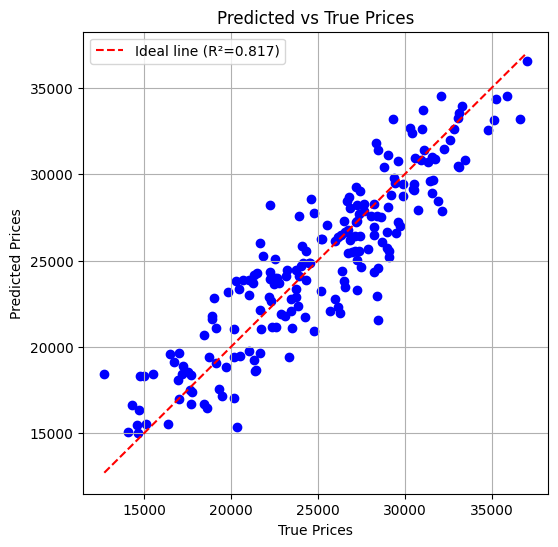

In [ ]:
# Scatter predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label=f'Ideal line (R²={r2_score(y_test, y_pred_lr):.3f})')
plt.xlabel('True Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs True Prices')
plt.legend()
plt.grid(True)
plt.show()


----------------------------------------